## Lab 2

Step 1 - Illustration of Non-Linear Data

Step 1a - Import Libraries

In [31]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
from sklearn.svm import SVC

Step 1b - Recreate the Plotting Function

In [32]:
# create a function to display model fitting

def plot_svc_decision_function(model, ax=None, plot_support=True):
    
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # create a grid for model evaluation
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)
    
    # plot boundary and margins
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    
    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, facecolors='none');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

Step 1c - Create Non-Linear Dummy Data

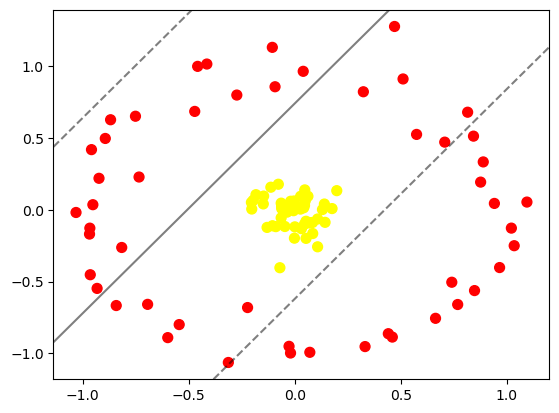

In [38]:
# example of non-linearly separable data
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)

clf = SVC(kernel='linear').fit(X, y)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf, plot_support=False);

Based on the example data above, no linear separating line was found that can serve as a data separator. Therefore, an alternative projection (perspective) of the data is required so that the data can be separated clearly. In this activity, the projection used is a radial-based projection. Define the radial function in the code.

In [39]:
r = np.exp(-(X**2).sum(1))

Because the radial projection cannot be sufficiently represented using a 2D model, the visualization plot is converted to a 3D model.

In [40]:
from mpl_toolkits import mplot3d
from ipywidgets import interact, fixed

def plot_3D(elev=30, azim=30, X=X, y=y):
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=50, cmap='autumn')
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('r')

interact(plot_3D, elev=[-90, 45, 30, 20 , 10], azip=(-180, 180),
         X=fixed(X), y=fixed(y))

interactive(children=(Dropdown(description='elev', index=2, options=(-90, 45, 30, 20, 10), value=30), IntSlide…

<function __main__.plot_3D(elev=30, azim=30, X=array([[ 4.71223073e-02,  1.39135860e-01],
       [-5.45082922e-01, -7.99191557e-01],
       [-8.93528418e-01,  4.97438550e-01],
       [-4.71806062e-01,  6.85863676e-01],
       [ 6.63583659e-01, -7.55625866e-01],
       [-1.46869595e-01,  9.60982330e-02],
       [-1.30701071e-01, -1.22266399e-01],
       [ 4.59178434e-02,  3.14063528e-02],
       [ 4.40961280e-01, -8.62730699e-01],
       [-6.20972203e-02,  2.51473895e-02],
       [-3.65085641e-02, -1.58082589e-02],
       [ 4.59792156e-01, -8.86312448e-01],
       [-6.41573973e-02,  4.67616438e-02],
       [ 5.28230461e-02, -7.92638551e-02],
       [-1.12945196e-01,  1.57808009e-01],
       [ 9.41063215e-01,  4.48093453e-02],
       [ 1.39430404e-01,  4.05141000e-02],
       [ 8.38693116e-02, -8.78057553e-02],
       [ 3.11759510e-02, -1.30997390e-01],
       [ 7.68037539e-01, -6.59389547e-01],
       [ 8.88548513e-01,  3.33990675e-01],
       [-1.05339904e-01, -1.10637300e-01],
       

Step 2 - Model Fitting

Although the data can be rendered separable, projecting N data points into an N-dimensional space increases computational burden. To address this, the radial basis function (RBF) kernel in Scikit-Learn is employed.

In [41]:
clf = SVC(kernel='rbf', C=1E6)
clf.fit(X, y)

SVC(C=1000000.0)

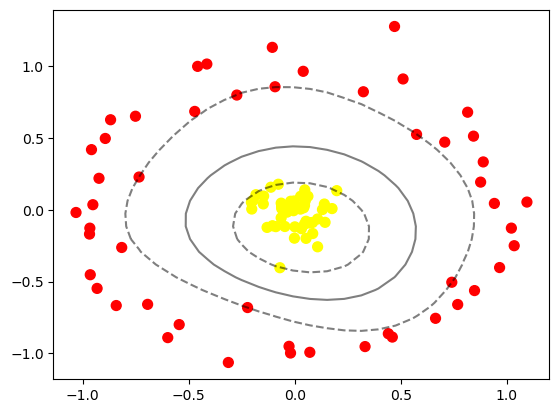

In [43]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf)
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
            s=300, lw=1, facecolors='none')